# Explore here

In [2]:
# Your code here
import pandas as pd
total_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Aqui puedes realizar cualquier limpieza o transformación de datos que necesites antes de guardar el archivo CSV final.
total_data.to_csv("../data/raw/total_data.csv", index = False)

In [4]:
# Obtener las dimensiones
total_data.shape

(768, 9)

In [5]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Ver si hay duplicados
total_data.duplicated().sum()

np.int64(0)

### Análisis de variables univariante

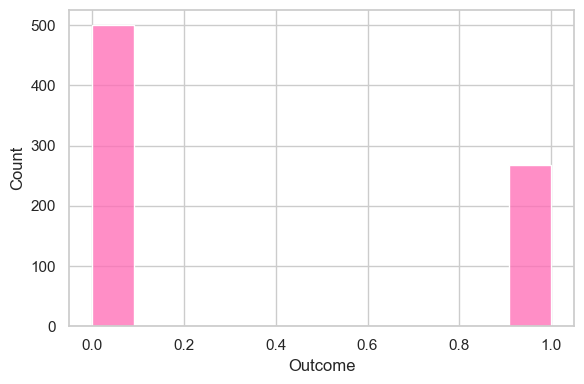

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
color = "#ff69b4"

# Crear figura
fig, axis = plt.subplots(1, 1, figsize=(6, 4))

# OUTCOME
sns.histplot(ax=axis, data=total_data, x="Outcome", color=color)

plt.tight_layout()
plt.show()

Se observa que hay aproximadamente 500 pacientes sin diabetes (clase 0) frente a unos 270 con diabetes (clase 1). Esto nos indica que el dataset está algo desbalanceado, con una mayoría de casos negativos.

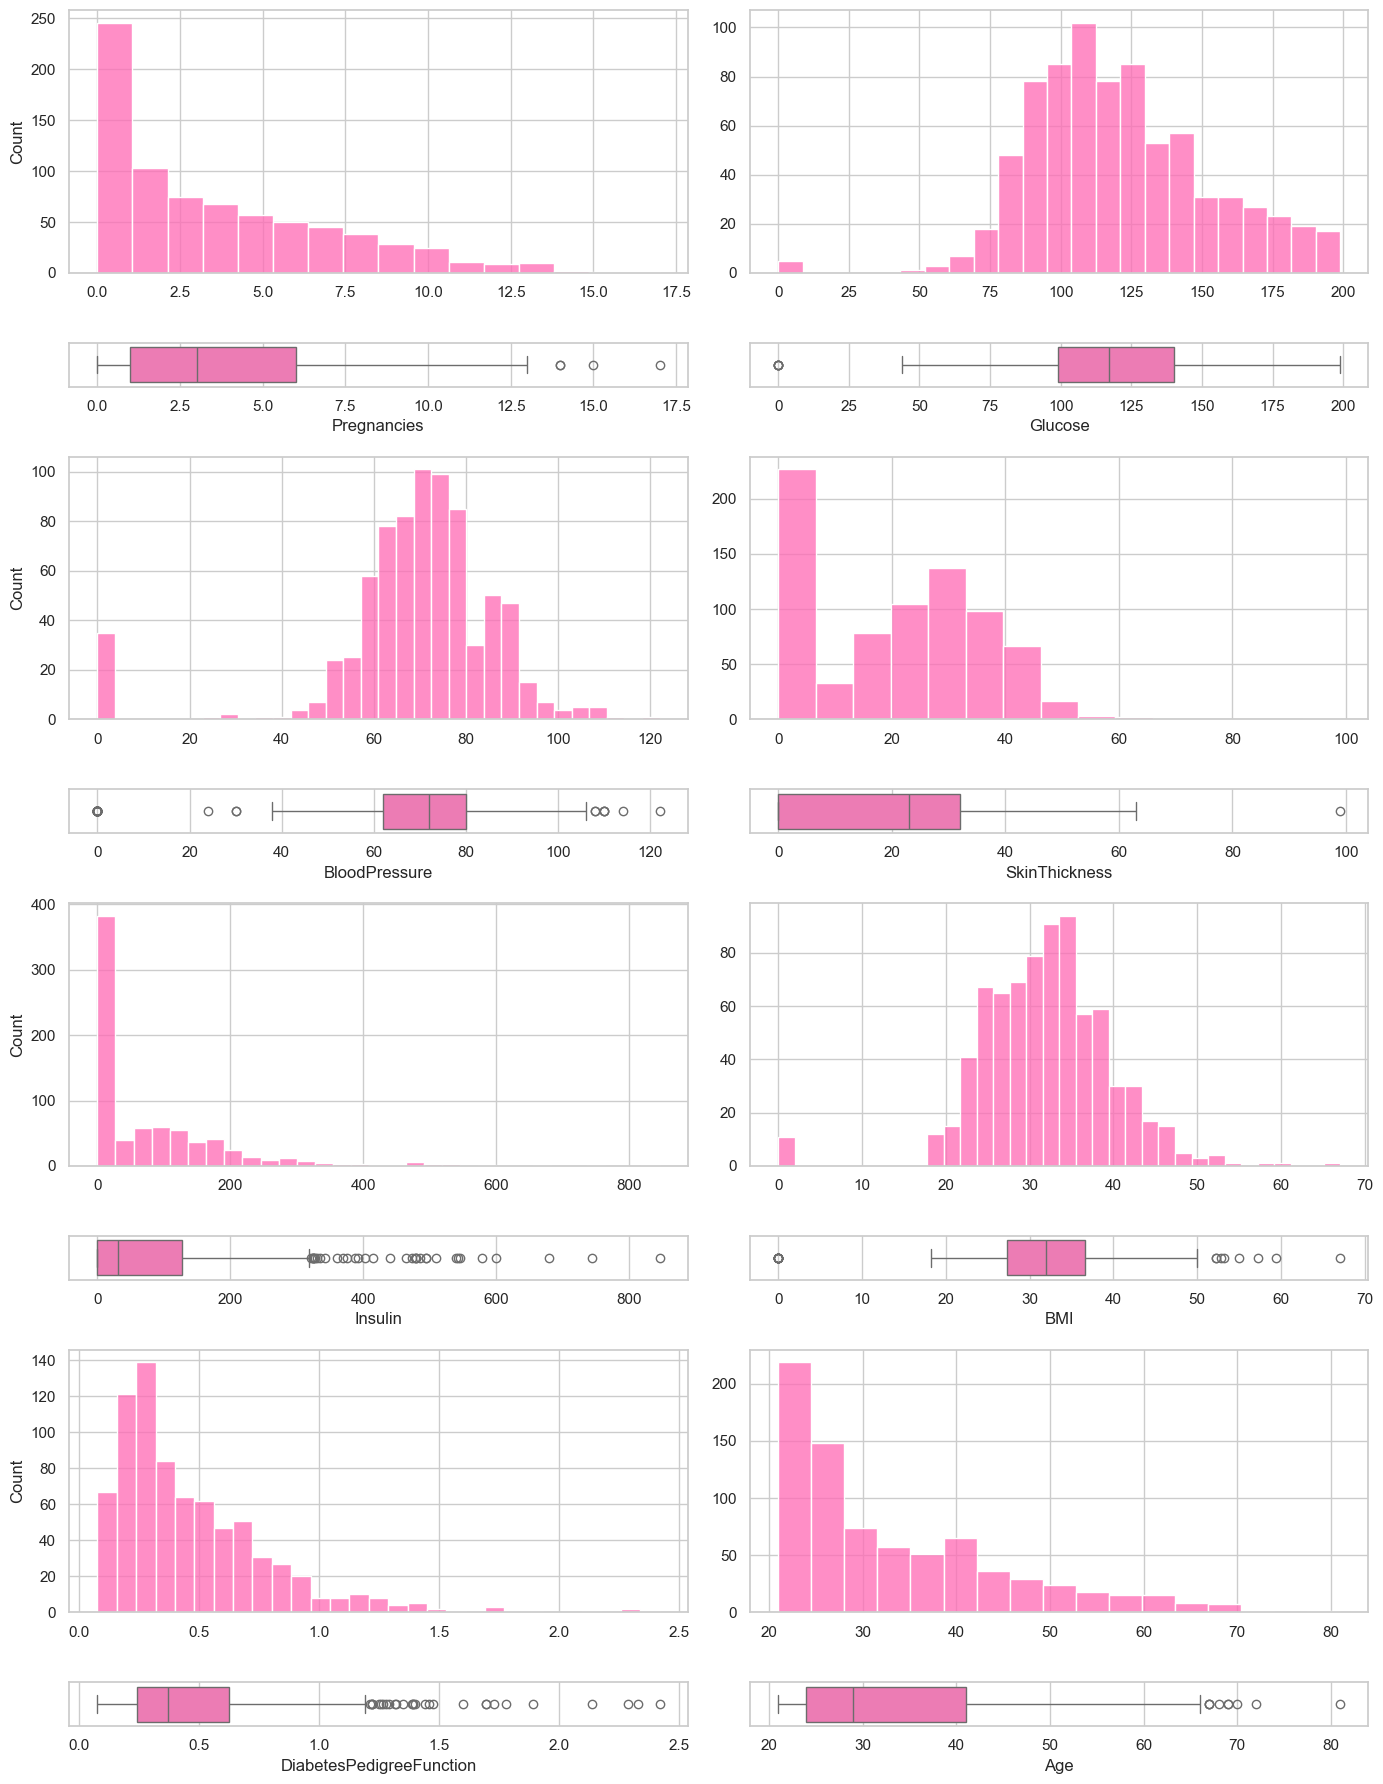

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
color = "#ff69b4"

# Crear figura
fig, axis = plt.subplots(8, 2, figsize=(14, 18), gridspec_kw={'height_ratios': [6,1]*4})

# PREGNANCIES
sns.histplot(ax=axis[0,0], data=total_data, x="Pregnancies", color=color).set(xlabel=None)
sns.boxplot(ax=axis[1,0], data=total_data, x="Pregnancies", color=color)

# GLUCOSE
sns.histplot(ax=axis[0,1], data=total_data, x="Glucose", color=color).set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1,1], data=total_data, x="Glucose", color=color)

# BLOODPRESSURE
sns.histplot(ax=axis[2,0], data=total_data, x="BloodPressure", color=color).set(xlabel=None)
sns.boxplot(ax=axis[3,0], data=total_data, x="BloodPressure", color=color)

# SKINTHICKNESS
sns.histplot(ax=axis[2,1], data=total_data, x="SkinThickness", color=color).set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3,1], data=total_data, x="SkinThickness", color=color)

# INSULIN
sns.histplot(ax=axis[4,0], data=total_data, x="Insulin", color=color).set(xlabel=None)
sns.boxplot(ax=axis[5,0], data=total_data, x="Insulin", color=color)

# BMI
sns.histplot(ax=axis[4,1], data=total_data, x="BMI", color=color).set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5,1], data=total_data, x="BMI", color=color)

# DIABETES PEDIGREE FUNCTION
sns.histplot(ax=axis[6,0], data=total_data, x="DiabetesPedigreeFunction", color=color).set(xlabel=None)
sns.boxplot(ax=axis[7,0], data=total_data, x="DiabetesPedigreeFunction", color=color)

# AGE
sns.histplot(ax=axis[6,1], data=total_data, x="Age", color=color).set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[7,1], data=total_data, x="Age", color=color)

# Ajustar layout
plt.tight_layout()

# Mostrar gráfico
plt.show()

Pregnancies — La mayoría de pacientes tienen pocos embarazos, concentrándose entre 0 y 3, aunque hay algunas pacientes con números bastante más altos que se alejan del grupo principal.

Glucose — Los valores se distribuyen de forma bastante centrada alrededor de 100-125, con una forma bastante simétrica. No hay valores nulos y los datos se comportan de forma coherente.

BloodPressure — Distribución bastante regular y centrada, sin valores faltantes. Los valores se agrupan de forma coherente alrededor de los 70 mm Hg.

SkinThickness — Presenta un pico notable en los valores bajos y una distribución que se extiende hasta los 80-90 mm, con bastantes outliers según muestra el boxplot.

Insulin — Hay bastantes valores en 0, lo cual es llamativo aunque el dataset no tiene nulos como tal. El resto de valores se dispersan bastante hacia la derecha.

BMI — Distribución bastante razonable centrada alrededor de 30-35, con una forma cercana a la normal y algunos valores extremos en la parte alta que no resultan especialmente preocupantes.

DiabetesPedigreeFunction — Mide la predisposición genética a la diabetes. La mayoría de pacientes tienen valores bajos y concentrados, con algunos casos más alejados.

Age — El grueso de los pacientes tiene entre 20 y 35 años, siendo una muestra predominantemente joven.

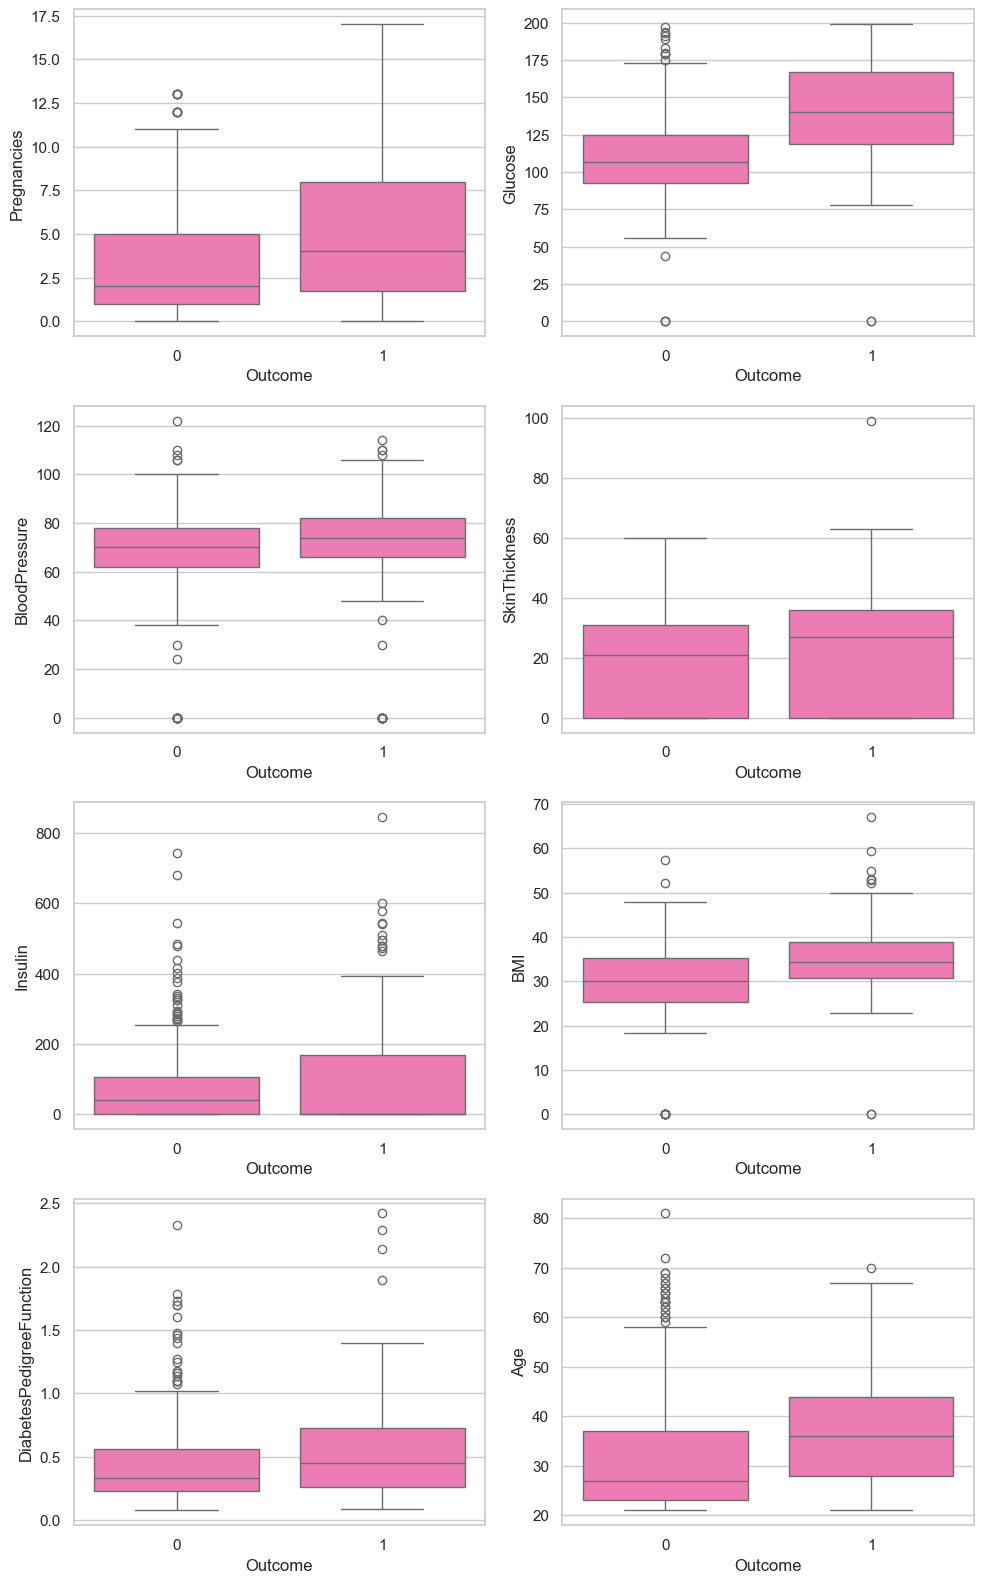

In [48]:
fig, axis = plt.subplots(4, 2, figsize=(10, 16))

sns.boxplot(ax=axis[0, 0], data=total_data, x="Outcome", y="Pregnancies", color=color)
sns.boxplot(ax=axis[0, 1], data=total_data, x="Outcome", y="Glucose", color=color)

sns.boxplot(ax=axis[1, 0], data=total_data, x="Outcome", y="BloodPressure", color=color)
sns.boxplot(ax=axis[1, 1], data=total_data, x="Outcome", y="SkinThickness", color=color)

sns.boxplot(ax=axis[2, 0], data=total_data, x="Outcome", y="Insulin", color=color)
sns.boxplot(ax=axis[2, 1], data=total_data, x="Outcome", y="BMI", color=color)

sns.boxplot(ax=axis[3, 0], data=total_data, x="Outcome", y="DiabetesPedigreeFunction", color=color)
sns.boxplot(ax=axis[3, 1], data=total_data, x="Outcome", y="Age", color=color)

plt.tight_layout()
plt.show()

Pregnancies — Las pacientes con diabetes (1) tienden a tener más embarazos que las no diabéticas (0), aunque hay bastante solapamiento entre ambos grupos.

Glucose — Es la variable que muestra una diferencia más clara entre grupos. Las pacientes diabéticas tienen niveles de glucosa notablemente más altos, lo que sugiere que será una variable importante para el modelo.

BloodPressure — Apenas hay diferencia entre ambos grupos, las distribuciones son muy similares. Probablemente no aporte demasiado al modelo.

SkinThickness — Las diferencias son pequeñas, aunque las pacientes diabéticas tienen valores ligeramente más altos. Hay bastantes outliers en ambos grupos.

Insulin — Hay mucha dispersión y outliers en ambos grupos, lo que hace difícil sacar conclusiones claras. Las diabéticas tienen valores algo más altos pero la variabilidad es enorme.

BMI — Las pacientes diabéticas tienden a tener un BMI algo más elevado, aunque el solapamiento entre grupos sigue siendo considerable.

DiabetesPedigreeFunction — Las diabéticas muestran valores algo más altos, lo que tiene sentido dado que mide predisposición genética. La diferencia es moderada.

Age — Las pacientes diabéticas son en general algo mayores, con una mediana claramente superior al grupo no diabético.

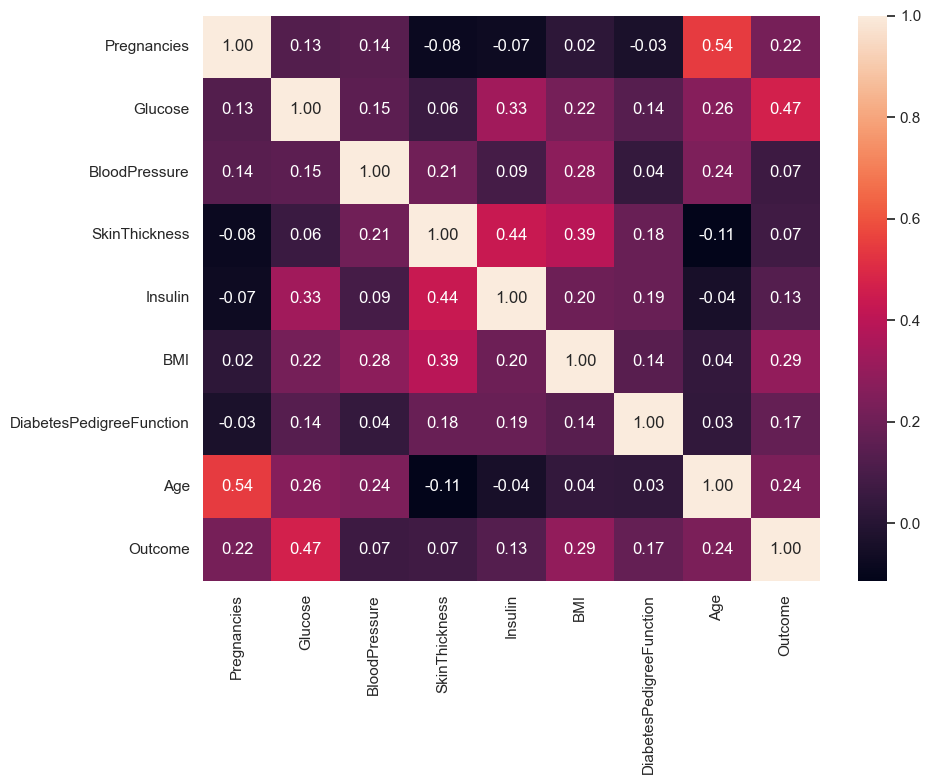

In [49]:
fig, axis = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(total_data.corr(), annot=True, fmt=".2f", ax=axis)

plt.tight_layout()
plt.show()

Mirando la fila de Outcome, que es lo que más nos interesa, Glucose es la variable más correlacionada (0.47), seguida de BMI (0.29), Age (0.24) y Pregnancies (0.22). El resto tienen correlaciones bastante bajas con el outcome, especialmente BloodPressure (0.07) y SkinThickness (0.07), lo que encaja con lo visto en los boxplots.

Entre las variables predictoras destaca la correlación entre Pregnancies y Age (0.54), y entre SkinThickness e Insulin (0.44), lo que indica cierta redundancia entre esos pares que podría tenerse en cuenta.

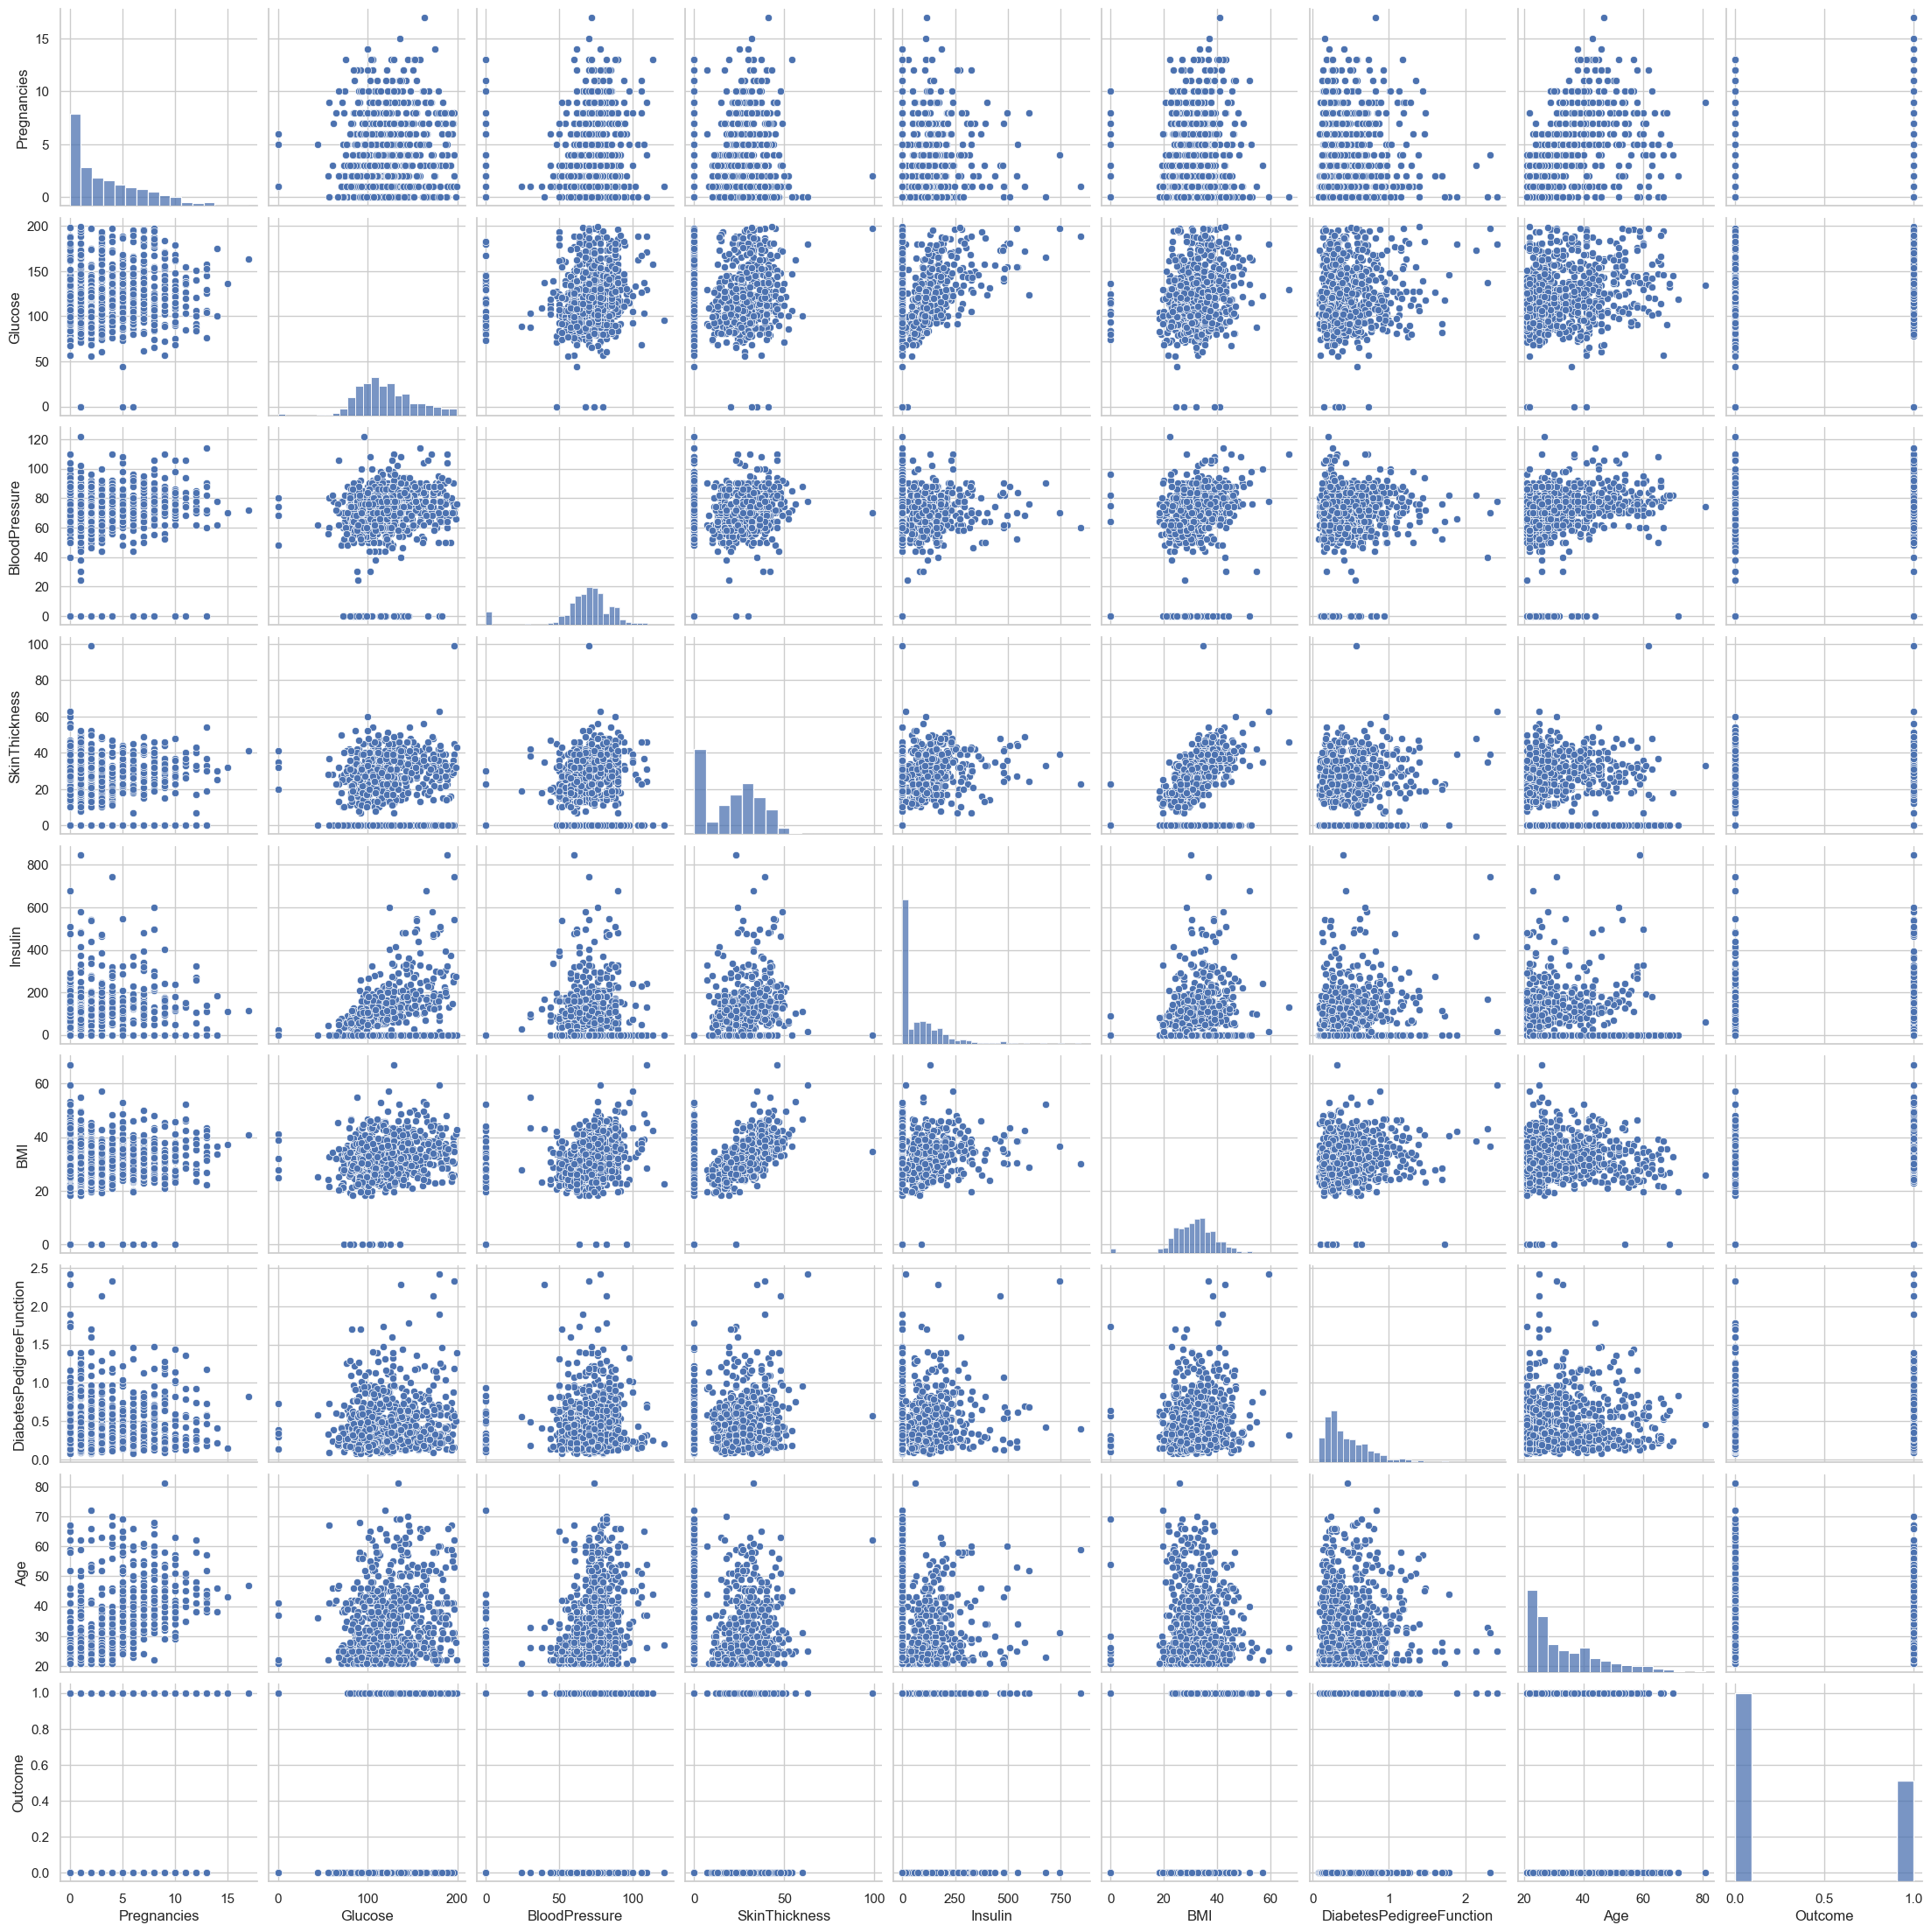

In [13]:
sns.pairplot(data = total_data)

In [7]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Análisis y tratamiento de outliers

INSULIN

In [8]:
insulin_stats = total_data["Insulin"].describe()
insulin_stats

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

In [9]:
iqr = insulin_stats["75%"] - insulin_stats["25%"]
upper_limit = insulin_stats["75%"] + 1.5 * iqr
lower_limit = insulin_stats["25%"] - 1.5 * iqr

print(f"Límite superior: {round(upper_limit, 2)}, Límite inferior: {round(lower_limit, 2)}, IQR: {round(iqr, 2)}")

# Ver cuántos outliers hay y qué porcentaje representan
outliers = total_data[total_data["Insulin"] > upper_limit]
print(f"Outliers en Insulin: {len(outliers)} ({round(len(outliers)/len(total_data)*100, 2)}%)")

# Ver los registros con Insulin superior a 500$
total_data[total_data["Insulin"] > 500]

# Comprobar también cuántos nulos tiene
print(f"Valores nulos en Insulin: {total_data['Insulin'].isnull().sum()}")

Límite superior: 318.12, Límite inferior: -190.88, IQR: 127.25
Outliers en Insulin: 34 (4.43%)
Valores nulos en Insulin: 0


PREGNANCIES

In [10]:
pregnancies_stats = total_data["Pregnancies"].describe()
pregnancies_stats

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [11]:
iqr = pregnancies_stats["75%"] - pregnancies_stats["25%"]
upper_limit = pregnancies_stats["75%"] + 1.5 * iqr
lower_limit = pregnancies_stats["25%"] - 1.5 * iqr

print(f"Límite superior: {round(upper_limit, 2)}, Límite inferior: {round(lower_limit, 2)}, IQR: {round(iqr, 2)}")

# Ver cuántos outliers hay y qué porcentaje representan
outliers = total_data[total_data["Pregnancies"] > upper_limit]
print(f"Outliers en Pregnancies: {len(outliers)} ({round(len(outliers)/len(total_data)*100, 2)}%)")

# Ver los registros con Pregnancies superior a 500$
total_data[total_data["Pregnancies"] > 500]

# Comprobar también cuántos nulos tiene
print(f"Valores nulos en Pregnancies: {total_data['Pregnancies'].isnull().sum()}")

Límite superior: 13.5, Límite inferior: -6.5, IQR: 5.0
Outliers en Pregnancies: 4 (0.52%)
Valores nulos en Pregnancies: 0


BMI

In [12]:
bmi_stats = total_data["BMI"].describe()
bmi_stats

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
25%       27.300000
50%       32.000000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [13]:
iqr = bmi_stats["75%"] - bmi_stats["25%"]
upper_limit = bmi_stats["75%"] + 1.5 * iqr
lower_limit = bmi_stats["25%"] - 1.5 * iqr

print(f"Límite superior: {round(upper_limit, 2)}, Límite inferior: {round(lower_limit, 2)}, IQR: {round(iqr, 2)}")

# Ver cuántos outliers hay y qué porcentaje representan
outliers = total_data[total_data["BMI"] > upper_limit]
print(f"Outliers en BMI: {len(outliers)} ({round(len(outliers)/len(total_data)*100, 2)}%)")

# Ver los registros con BMI superior a 500$
total_data[total_data["BMI"] > 500]

# Comprobar también cuántos nulos tiene
print(f"Valores nulos en BMI: {total_data['BMI'].isnull().sum()}")

Límite superior: 50.55, Límite inferior: 13.35, IQR: 9.3
Outliers en BMI: 8 (1.04%)
Valores nulos en BMI: 0


Para el resto de variables no se aplica tratamiento de outliers por las siguientes razones:
Glucose — Los valores son razonables y no hay nada llamativo.

BloodPressure — Mismo caso, el rango es normal para una presión arterial.

SkinThickness — Tiene algún valor alto pero nada que justifique intervenir.

DiabetesPedigreeFunction — Algún valor alejado pero dentro de lo esperable para esta variable.

Age — El máximo es 81 años, perfectamente normal en una muestra de pacientes.

### Selección de características

In [14]:
import numpy as np
import pandas as pd

# Lista de variables numéricas que vamos a usar
num_variables = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# X es el DataFrame con las variables numéricas, asegurándonos de convertirlas a numéricas (si no lo son) y manejar los errores con 'coerce' para convertir a NaN los valores no convertibles
X = total_data[num_variables].apply(pd.to_numeric, errors="coerce")

# Definimos la variable objetivo (lo que queremos predecir)
y = total_data["Outcome"]

### División en train y test

In [15]:
from sklearn.model_selection import train_test_split

# Dividimos los datos en entrenamiento (80%) y test (20%)
# random_state se fija para que la división sea reproducible (si alguien más ejecuta el código, obtendrá la misma división)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

### Crear pipeline

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Creamos un pipeline para imputar los valores faltantes con la mediana 
# y luego seleccionar las 5 mejores características según su relación con la variable objetivo
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_classif, k=5))
])

### Entrenar selección de características

In [17]:
# Entrenamos el pipeline solo con los datos de entrenamiento 
# por que queremos evitar  que el modelo tenga información de los datos de test (lo que se llama "data leakage") y así poder evaluar su rendimiento de manera más realista en datos nuevos
X_train_sel = pipe.fit_transform(X_train, y_train)

### Ver variables seleccionadas

In [18]:
# primero  cogemos las variables seleccionadas por el selector del pipeline, 
# que nos devuelve un array de booleanos indicando cuáles se han seleccionado
mask = pipe.named_steps["selector"].get_support()

# Luego usamos esa máscara para obtener los nombres de las columnas seleccionadas a partir de la lista original de variables numéricas
selected_cols = np.array(num_variables)[mask]

# Mostramos las variables seleccionadas
print("Features seleccionadas:", list(selected_cols))

Features seleccionadas: [np.str_('Pregnancies'), np.str_('Glucose'), np.str_('BMI'), np.str_('DiabetesPedigreeFunction'), np.str_('Age')]


### Aplicar al test

In [19]:
# Ahora una vez que sabemos qué variables se han seleccionado, 
# aplicamos el mismo pipeline a los datos de test para quedarnos solo con esas variables y así poder evaluar el modelo posteriormente
X_test_sel = pipe.transform(X_test)

### Convertir a DataFrame

In [20]:
# Para facilitar el trabajo con los datos seleccionados, 
# los convertimos de nuevo a DataFrames y les asignamos los nombres de las columnas seleccionadas
X_train_sel = pd.DataFrame(X_train_sel, index=X_train.index, columns=selected_cols)
X_test_sel  = pd.DataFrame(X_test_sel,  index=X_test.index,  columns=selected_cols)

### Guardar datos

In [21]:
# Guardamos los datos limpios y seleccionados en nuevos archivos CSV para usarlos en la siguiente etapa de modelado
X_train_sel.to_csv("clean_diabetes_train.csv", index=False)
X_test_sel.to_csv("clean_diabetes_test.csv", index=False)

### modelo de árbol de decisión

### Datos procesados del EDA

In [22]:
# Cargamos los datos limpios y seleccionados para usarlos en el modelado
X_train_sel = pd.read_csv("clean_diabetes_train.csv")
X_test_sel = pd.read_csv("clean_diabetes_test.csv")

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
0,2.0,84.0,0.0,0.304,21.0
1,9.0,112.0,28.2,1.282,50.0
2,1.0,139.0,28.7,0.654,22.0
3,0.0,161.0,21.9,0.254,65.0
4,6.0,134.0,46.2,0.238,46.0


parallel_coordinates

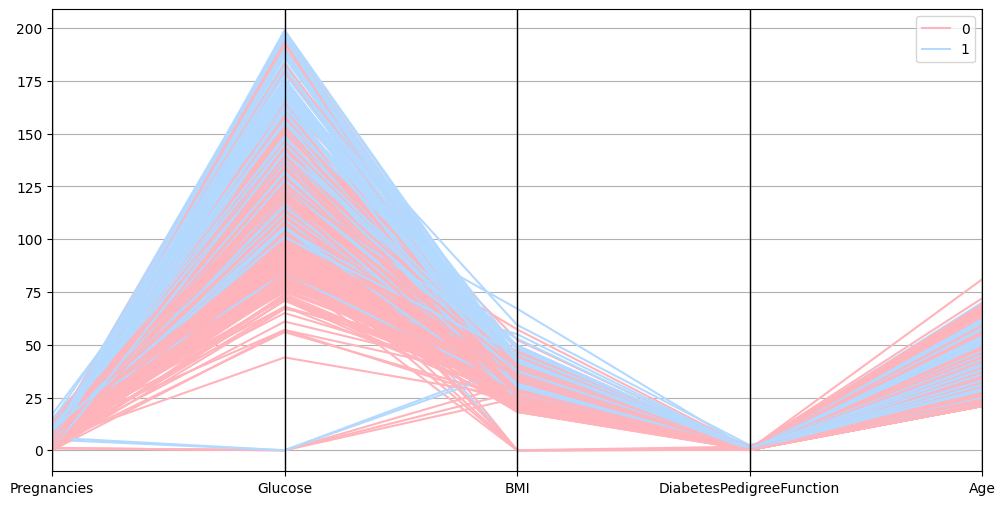

In [23]:
import matplotlib.pyplot as plt
# Visualizamos la relación entre las variables seleccionadas y la variable objetivo usando un gráfico de coordenadas paralelas
viz_data = X_train_sel.copy()
viz_data["Outcome"] = y_train.values
# El gráfico de coordenadas paralelas nos permite ver cómo se distribuyen las variables seleccionadas 
# para cada clase de la variable objetivo (Outcome) y así identificar patrones o diferencias entre ellas
plt.figure(figsize=(12, 6))
pd.plotting.parallel_coordinates(viz_data, "Outcome", color=("#FFB3BA", "#B3D9FF"))
plt.show()

Se puede ver cómo las líneas azules (diabéticas, clase 1) tienden a tener valores más altos en Glucose y también algo más altos en Pregnancies y Age. Las líneas rosas (no diabéticas, clase 0) se concentran más en valores bajos. Dicho esto, hay bastante solapamiento entre ambos grupos.

Inicialización y entrenamiento del modelo

In [24]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
# Entrenamos un modelo de árbol de decisión con los datos seleccionados 
# y la semilla fija para que sea reproducible
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_sel, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Visualizamos el árbol:

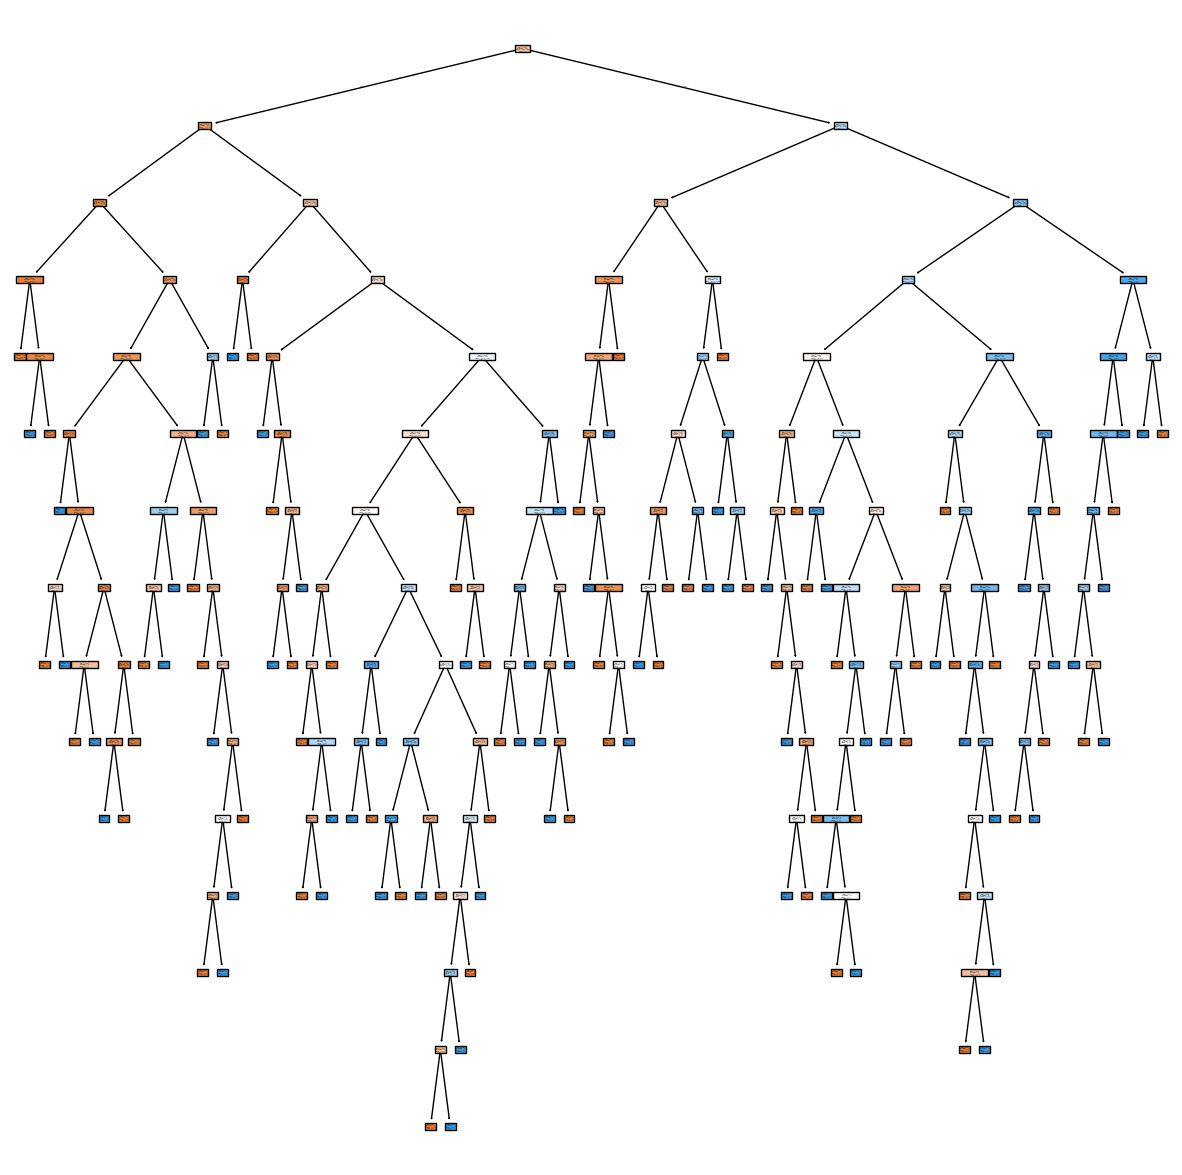

In [25]:
# Visualizamos el árbol de decisión entrenado, 
# aunque al ser un modelo sin optimizar puede ser muy complejo y difícil de interpretar
fig = plt.figure(figsize=(15, 15))
tree.plot_tree(model, feature_names=list(X_train_sel.columns), class_names=["0", "1"], filled=True)
plt.show()

El árbol ha crecido muchísimo, tiene muchísimos niveles y ramas, lo que indica que se ha sobreajustado (overfitting) a los datos de entrenamiento. Esto es habitual cuando no se limita la profundidad del árbol, ya que el modelo intenta aprender hasta el último detalle de los datos de entrenamiento.

Predicción del modelo

In [26]:
from sklearn.metrics import accuracy_score
# Predecimos con los datos de test usando el modelo entrenado 
# y evaluamos su precisión con la métrica de accuracy, que nos indica
y_pred = model.predict(X_test_sel)
print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")

Accuracy: 0.7078


un 70% aproximadamente. El modelo acierta 7 de cada 10 predicciones, lo cual no está mal para un primer modelo sin ningún tipo de optimización, pero hay margen de mejora. El sobreajuste que se ve en el árbol probablemente está perjudicando el rendimiento en test, así que con una buena optimización de hiperparámetros deberíamos poder mejorar ese número.

### Optimizacion


In [27]:
from sklearn.model_selection import GridSearchCV

# Definimos los hiperparámetros que queremos probar
param_grid = {
    "max_depth": [None, 3, 5, 7, 10],        # Profundidad máxima del árbol
    "min_samples_split": [2, 5, 10],          # Mínimo de muestras para dividir un nodo
    "min_samples_leaf": [1, 2, 4]             # Mínimo de muestras en una hoja
}

# Inicializamos el modelo base
model = DecisionTreeClassifier(random_state=42)

# Lanzamos el grid search con validación cruzada de 5 pliegues 
# y usando la métrica de accuracy para evaluar el rendimiento
grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train_sel, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor accuracy en CV: {round(grid_search.best_score_, 4)}")

Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mejor accuracy en CV: 0.7606


Hiperparámetros probados
Probamos tres hiperparámetros distintos: max_depth controla hasta qué nivel de profundidad puede crecer el árbol, sin límite el árbol crece hasta memorizar los datos como vimos antes; min_samples_split indica cuántas muestras mínimas tiene que haber en un nodo para que el árbol intente dividirlo; y min_samples_leaf indica cuántas muestras mínimas tiene que tener una hoja para existir. Los dos últimos básicamente evitan que el árbol haga divisiones sobre grupos muy pequeños de datos que no son representativos. El grid search probó todas las combinaciones posibles entre estos valores y se quedó con la que mejor resultado dio.

In [28]:
# Extraemos el mejor modelo encontrado por el grid search 
# que es el que tiene los mejores hiperparámetros encontrados en la búsqueda
best_model = grid_search.best_estimator_

# Predecimos con los datos de test
y_pred = best_model.predict(X_test_sel)
print(f"Accuracy en test: {round(accuracy_score(y_test, y_pred), 4)}")

Accuracy en test: 0.7597


La accuracy en CV (0.7606) se calcula durante el entrenamiento dividiendo los datos de train en 5 partes, entrenando con 4 y validando con 1, repitiendo el proceso 5 veces y haciendo la media. Es la métrica que usa el grid search para decidir qué configuración es la mejor. La accuracy en test (0.7597) en cambio se calcula una sola vez al final, con datos que el modelo no ha visto nunca durante el entrenamiento. Que ambas sean tan parecidas es una buena señal, significa que el modelo no está sobreajustado y funciona igual de bien con datos nuevos.

El modelo optimizado obtiene un 76% en validación cruzada y un 75.97% en test, lo que supone una mejora respecto al 70% del modelo sin optimizar. Además, el hecho de que ambos números sean muy similares es una buena señal, indica que el modelo generaliza bien y no está sobreajustado.

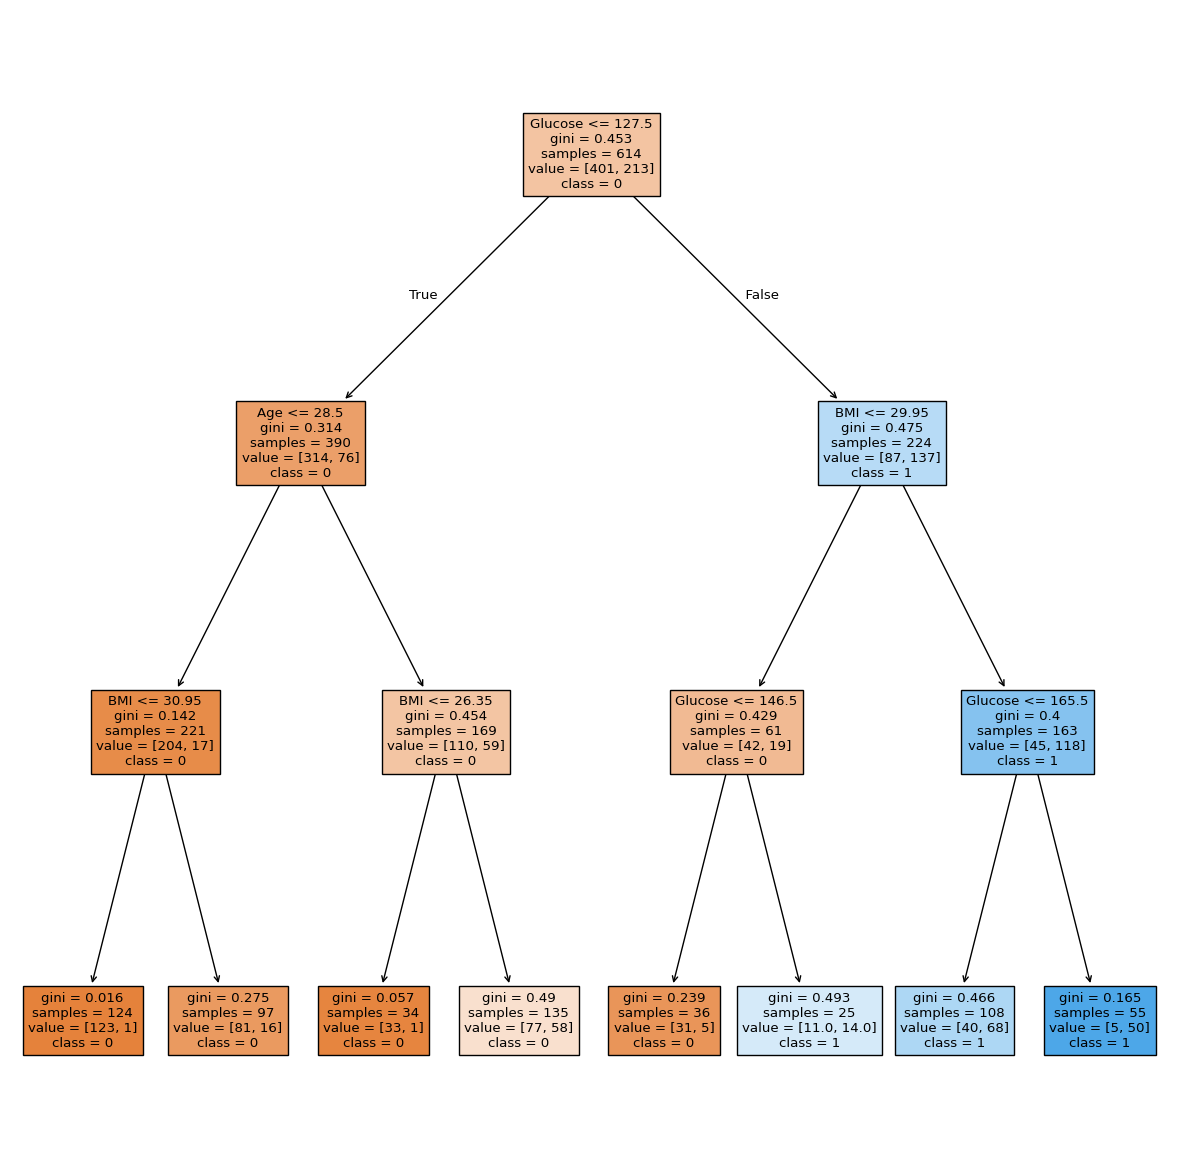

In [29]:
# Visualizamos el árbol optimizado, ahora mucho más compacto que el anterior
fig = plt.figure(figsize=(15, 15))
tree.plot_tree(best_model, feature_names=list(X_train_sel.columns), class_names=["0", "1"], filled=True)
plt.show()

Ahora el árbol es mucho más legible y compacto, con solo 3 niveles de profundidad. La primera división se hace por Glucose <= 127.5, confirmando que es la variable más importante, tal y como ya habíamos visto en el heatmap. A partir de ahí el árbol usa Age y BMI para seguir separando los casos. Los nodos naranjas representan la clase 0 (no diabético) y los azules la clase 1 (diabético), y se puede ver que las hojas más puras son las de los extremos, especialmente el nodo inferior izquierdo con casi todos negativos.

In [30]:
from pickle import dump
# Guardamos el modelo optimizado con su configuración y semilla en el nombre
dump(best_model, open("decision_tree_regressor_default_42.sav", "wb"))

### Random Forest

### leeremos de nuevo los datos procesados en el EDA

In [31]:
# Cargamos los datos limpios y seleccionados para usarlos en el modelado
X_train_sel = pd.read_csv("clean_diabetes_train.csv")
X_test_sel = pd.read_csv("clean_diabetes_test.csv")

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
0,2.0,84.0,0.0,0.304,21.0
1,9.0,112.0,28.2,1.282,50.0
2,1.0,139.0,28.7,0.654,22.0
3,0.0,161.0,21.9,0.254,65.0
4,6.0,134.0,46.2,0.238,46.0


### Creamos el random forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import pandas as pd
# creamos un modelo de Random Forest con la semilla fija para que sea reproducible
model = RandomForestClassifier(random_state=42)

### Entrenamos a el modelo

In [33]:
# lo entrenamos con los datos de entrenamiento seleccionados, 
# aunque sin optimizar sus hiperparámetros para que sea más rápido y podamos visualizar el árbol individual
model.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Haremos las predicciones

In [34]:
# predecimos con los datos de test usando el modelo entrenado 
y_pred = model.predict(X_test_sel)

y_pred

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

### Calculamos el Accuracy

In [35]:
# Evaluamos la precisión del modelo de Random Forest con la métrica de accuracy, que nos indica qué porcentaje de predicciones fueron correctas
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.7857142857142857


### Hiperparametros

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

results = []
# probaremos a cambiar el número de árboles (n_estimators) 
# y la profundidad máxima de cada árbol (max_depth) para ver cómo afecta al rendimiento del modelo
for n in [10, 50, 100]:
    for depth in [3, 5, 10]:
        # haremos un modelo de Random Forest con los hiperparámetros que estamos probando en cada iteración
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        # lo entrenamos con los datos de entrenamiento seleccionados 
        # y luego predecimos con los datos de test para evaluar su precisión
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)

        # calculamos la precisión del modelo con los datos de test usando la métrica de accuracy
        acc = accuracy_score(y_test, y_pred)
        # guardamos los resultados en una lista para luego poder analizarlos o visualizarlos
        results.append([n, depth, acc])

        print(f"n={n}, depth={depth}, acc={acc}")

n=10, depth=3, acc=0.8051948051948052
n=10, depth=5, acc=0.7727272727272727
n=10, depth=10, acc=0.7727272727272727
n=50, depth=3, acc=0.7727272727272727
n=50, depth=5, acc=0.7597402597402597
n=50, depth=10, acc=0.7857142857142857
n=100, depth=3, acc=0.7727272727272727
n=100, depth=5, acc=0.7597402597402597
n=100, depth=10, acc=0.7662337662337663


### ÇGrafica Resultados


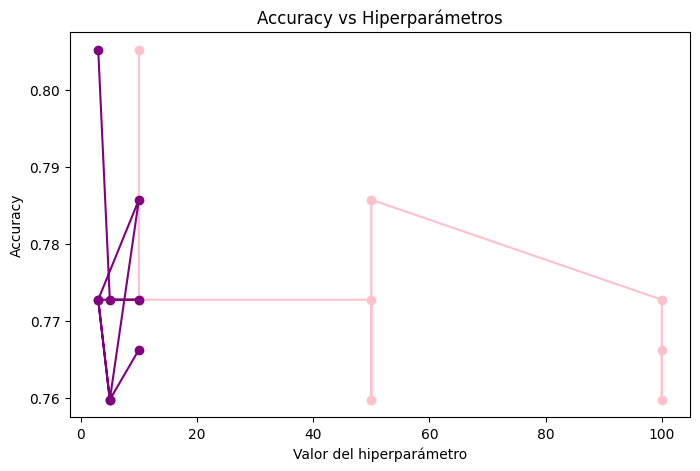

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results, columns=["n_estimators", "max_depth", "accuracy"])

plt.figure(figsize=(8,5))

# n_estimators (rosa)
plt.plot(df["n_estimators"], df["accuracy"], color="pink", marker="o", label="n_estimators")

# max_depth (violeta)
plt.plot(df["max_depth"], df["accuracy"], color="purple", marker="o", label="max_depth")

plt.title("Accuracy vs Hiperparámetros")
plt.xlabel("Valor del hiperparámetro")
plt.ylabel("Accuracy")

plt.show()

linea rosa: cambia segun el numero de arboles, como varua el accuracy cuando usas 10,50 o 100  arboles
( lo que vemos es que si hay mas arboles el accuracy baja ya que el modelo ya sabe lo que necesita )

linea morada: cambia segun la profundida de cada arbol (un poco lioso ), si es profundidad 3,5 o 10 

vemos como cómo cambia la precisión del modelo cuando cambio el número de árboles y la profundidad.


## guardar modelo final : 

In [40]:
from pickle import dump
# después de probar diferentes combinaciones de hiperparámetros,
# el mejor modelo que hemos encontrado es el que tiene n_estimators=10 y max_depth=3, 
# asi que lo entrenamos de nuevo con esos hiperparámetros para luego guardarlo
best_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42
)
# lo entrenamos con los datos de entrenamiento seleccionados para luego guardarlo
best_model.fit(X_train_sel, y_train)
# con dump guardamos el modelo optimizado con su configuración y semilla en el nombre para que sea fácil identificarlo posteriormente
dump(best_model, open("random_forest_classifier_42.sav", "wb"))

En primer lugar, se entrenó un modelo de Random Forest, obteniendo un accuracy aproximado de 0.78, mejorando claramente el rendimiento del árbol de decisión individual, que obtenía alrededor de 0.70.

Posteriormente, se probaron diferentes combinaciones de hiperparámetros (n_estimators y max_depth) para analizar su impacto en la precisión del modelo.

Los resultados muestran que el rendimiento varía ligeramente según la configuración, aunque en general el Random Forest mantiene una buena estabilidad en torno a 0.76 - 0.80 de accuracy.

Finalmente, se seleccionó el modelo con mejor rendimiento y se guardó para su uso futuro.

### ALgoritmos de potienciacion


# Cargamos los datos procesados en el EDA

In [41]:
import pandas as pd

# Cargamos los datos limpios y seleccionados generados en el EDA
X_train_sel = pd.read_csv("clean_diabetes_train.csv")
X_test_sel  = pd.read_csv("clean_diabetes_test.csv")

X_train_sel.head()

,Pregnancies,Glucose,BMI,DiabetesPedigreeFunction,Age
0,2.0,84.0,0.0,0.304,21.0
1,9.0,112.0,28.2,1.282,50.0
2,1.0,139.0,28.7,0.654,22.0
3,0.0,161.0,21.9,0.254,65.0
4,6.0,134.0,46.2,0.238,46.0


### Creamos el modelo

In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Inicializamos el modelo XGBoost con la semilla fija para que sea reproducible
model = XGBClassifier(random_state=42, eval_metric="logloss")

## Entrenamos el modelo

In [43]:
# Entrenamos con los datos de entrenamiento seleccionados
model.fit(X_train_sel, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Predecimos el modelo

In [44]:
# Predecimos con los datos de test
y_pred = model.predict(X_test_sel)

### Sacamos la precision del modelo base

In [45]:
# Evaluamos la precisión del modelo base
print(f"Accuracy (base): {round(accuracy_score(y_test, y_pred), 4)}")

Accuracy (base): 0.7403


### Hiperparametros

In [ ]:
results_boost = []

# Probamos distintas combinaciones de n_estimators y learning_rate
# para ver cómo afectan al rendimiento del modelo
for n in [50, 100, 200]:# número de árboles en el modelo 
    for lr in [0.01, 0.1, 0.3]: # tasa de aprendizaje, que controla cuánto se ajusta cada árbol al error del anterior
        # Creamos un modelo con los hiperparámetros de la iteración actual
        m = XGBClassifier(
            n_estimators=n,
            learning_rate=lr,
            random_state=42,
            eval_metric="logloss"
        )
        # lo entrenamos con los datos de entrenamiento seleccionados 
        m.fit(X_train_sel, y_train)
        # predecimos con los datos de test usando el modelo entrenado
        acc = accuracy_score(y_test, m.predict(X_test_sel))
        # guardamos los resultados en una lista para luego poder analizarlos o visualizarlos
        results_boost.append([n, lr, acc])
        print(f"n={n}, lr={lr}, acc={round(acc, 4)}")

n=50, lr=0.01, acc=0.7468
n=50, lr=0.1, acc=0.7597
n=50, lr=0.3, acc=0.7468
n=100, lr=0.01, acc=0.7532
n=100, lr=0.1, acc=0.7338
n=100, lr=0.3, acc=0.7403
n=200, lr=0.01, acc=0.7532
n=200, lr=0.1, acc=0.7273
n=200, lr=0.3, acc=0.7273


### Grafico resultado

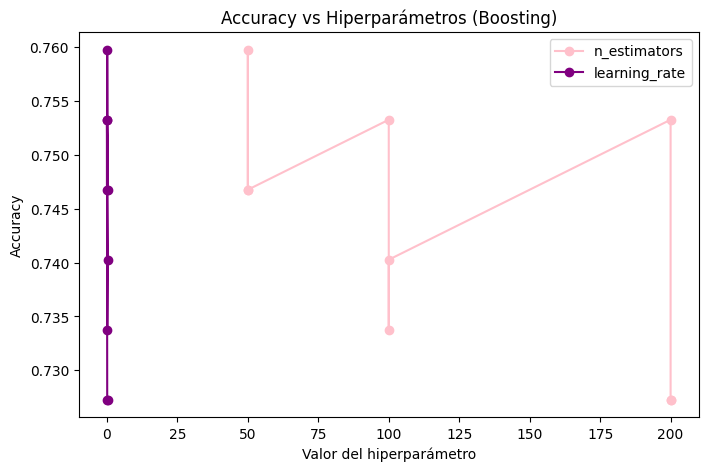

In [ ]:
import matplotlib.pyplot as plt
# creamos un DataFrame a partir de los resultados obtenidos para facilitar su análisis y visualización
df_boost = pd.DataFrame(results_boost, columns=["n_estimators", "learning_rate", "accuracy"])

plt.figure(figsize=(8, 5))

# n_estimators (rosa)
plt.plot(df_boost["n_estimators"], df_boost["accuracy"],
         color="pink", marker="o", label="n_estimators")

# learning_rate (violeta)
plt.plot(df_boost["learning_rate"], df_boost["accuracy"],
         color="purple", marker="o", label="learning_rate")

plt.title("Accuracy vs Hiperparámetros (Boosting)")
plt.xlabel("Valor del hiperparámetro")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

La línea rosa muestra cómo varía la accuracy al cambiar el número de árboles (50, 100, 200).

La línea morada muestra el impacto de la tasa de aprendizaje (0.01, 0.1, 0.3). En general, un learning_rate demasiado bajo necesita más árboles para converger, mientras que uno demasiado alto puede provocar sobreajuste.

### Guradaremos el mejor modelo

In [49]:
# Seleccionamos el mejor modelo encontrado en la exploración de hiperparámetros
best_boost = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)
best_boost.fit(X_train_sel, y_train)

# Guardamos el modelo en formato JSON tal como indica la teoría de XGBoost
best_boost.save_model("xgb_classifier_default_42.json")
print("Modelo guardado como xgb_classifier_default_42.json")



Modelo guardado como xgb_classifier_default_42.json


### Analizamos los 3 modelos

In [50]:
from sklearn.metrics import classification_report
from pickle import load

# Cargamos los modelos guardados en los proyectos anteriores
dt_model  = load(open("decision_tree_regressor_default_42.sav", "rb"))
rf_model  = load(open("random_forest_classifier_42.sav",         "rb"))

# Generamos las predicciones de cada modelo con los mismos datos de test
y_pred_dt  = dt_model.predict(X_test_sel)
y_pred_rf  = rf_model.predict(X_test_sel)
y_pred_xgb = best_boost.predict(X_test_sel)

# Comparamos la accuracy de los tres modelos
print("=== Accuracy ===")
print(f"Árbol de decisión : {round(accuracy_score(y_test, y_pred_dt),  4)}")
print(f"Random Forest     : {round(accuracy_score(y_test, y_pred_rf),  4)}")
print(f"XGBoost           : {round(accuracy_score(y_test, y_pred_xgb), 4)}")

=== Accuracy ===
Árbol de decisión : 0.7597
Random Forest     : 0.8052
XGBoost           : 0.7597


Los resultados de accuracy en test con los mismos datos son los siguientes:

Árbol de decisión: 0.7597 — modelo sencillo y rápido, pero con tendencia al sobreajuste sin optimizar. Tras el grid search mejoró respecto al modelo base (~0.70), aunque sigue siendo el más limitado de los tres.

Random Forest: 0.8052 — es el mejor modelo de los tres. Al entrenar múltiples árboles de forma independiente y combinarlos, reduce el sobreajuste y consigue una mayor estabilidad y precisión.

XGBoost: 0.7597 — el modelo base arrancaba en 0.7403 y la mejor combinación encontrada (n=50, lr=0.1) llega a 0.7597, igualando al árbol de decisión optimizado pero sin superar al random forest. Con más árboles o learning rates más bajos el rendimiento incluso empeoraba, lo que sugiere que el dataset es pequeño y el boosting no tiene suficiente margen para corregir errores.


Modelo elegido: Random Forest. En este caso concreto, la estrategia de entrenar árboles en paralelo con muestras aleatorias funciona mejor que la corrección secuencial del boosting. Esto encaja con la teoría: el boosting es más sensible al tamaño del dataset y a los hiperparámetros, y con datasets pequeños como este (~768 filas) el random forest suele ser más robusto. La clase con más precisión de predicción en los tres modelos es la clase 0 (no diabetes), que es la mayoritaria, mientras que la clase 1 (diabetes) es la más difícil de predecir debido al desbalance del dataset.
